[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/MecanicaCeleste/blob/main/Evaluaciones/Problemset3PenduloDoble.ipynb)

# Parte **b** del problema 3 del Problemset 3 de Mecánica celeste.

# Péndulo doble numérico

# Ecuaciones de movimiento

$$x_1 = l_1 \sin\theta_1$$
$$y_1 = l_1 \cos\theta_1$$
$$x_2 = l_1 \sin\theta_1 + l_2 \sin\theta_2$$
$$y_2 = l_1 \cos\theta_1 + l_2 \cos\theta_2$$

Eje $x$ positivo a la derecha, eje $y$ positivo hacia abajo

# Solución simbólica usando `SymPy`

In [79]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import sympy as sp
from sympy.physics.mechanics import dynamicsymbols, init_vprinting, LagrangesMethod
init_vprinting()

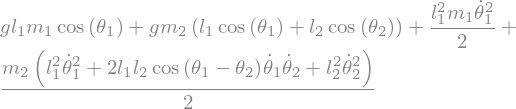

In [85]:
t = sp.Symbol("t")
l1, l2, m1, m2, g = sp.symbols("l_1 l_2 m_1 m_2 g", real=True, positive=True)

theta1, theta2 = dynamicsymbols("theta_1 theta_2")

x1 = l1*sp.sin(theta1)
y1 = l1*sp.cos(theta1)
x2 = l1*sp.sin(theta1) + l2*sp.sin(theta2)
y2 = l1*sp.cos(theta1) + l2*sp.cos(theta2)

v1_sq = x1.diff(t)**2 + y1.diff(t)**2
v2_sq = x2.diff(t)**2 + y2.diff(t)**2

T = sp.Rational(1, 2) * (m1*v1_sq + m2*v2_sq)
U = -m1*g*y1 - m2*g*y2
L = T - U
display(sp.simplify(L))

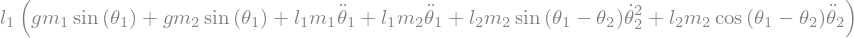

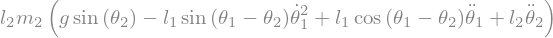

In [77]:
# Instanciar el método
LM = LagrangesMethod(L, [theta1, theta2])

# Formar las ecuaciones
eoms = LM.form_lagranges_equations()

# Simplificar e imprimir
eq1 = sp.trigsimp(eoms[0])
eq2 = sp.trigsimp(eoms[1])

display(eq1)
display(eq2)

# Vamos a construír el lagrangiano operando simbólicamente con `SymPy`

```python
def EulerLagrange(L, q, q_dot):
        dL_dq = L.diff(q)
        dL_dq_dot = L.diff(q_dot)
        dt_dL_dq_dot = dL_dq_dot.diff(t)
        return dt_dL_dq_dot - dL_dq

eq1 = EulerLagrange(L, theta1, theta1_dot)
eq2 = EulerLagrange(L, theta2, theta2_dot)
```

In [78]:
sp.print_latex(eq1)
print("\n")
sp.print_latex(eq2)

l_{1} \left(g m_{1} \sin{\left(\theta_{1}{\left(t \right)} \right)} + g m_{2} \sin{\left(\theta_{1}{\left(t \right)} \right)} + l_{1} m_{1} \frac{d^{2}}{d t^{2}} \theta_{1}{\left(t \right)} + l_{1} m_{2} \frac{d^{2}}{d t^{2}} \theta_{1}{\left(t \right)} + l_{2} m_{2} \sin{\left(\theta_{1}{\left(t \right)} - \theta_{2}{\left(t \right)} \right)} \left(\frac{d}{d t} \theta_{2}{\left(t \right)}\right)^{2} + l_{2} m_{2} \cos{\left(\theta_{1}{\left(t \right)} - \theta_{2}{\left(t \right)} \right)} \frac{d^{2}}{d t^{2}} \theta_{2}{\left(t \right)}\right)


l_{2} m_{2} \left(g \sin{\left(\theta_{2}{\left(t \right)} \right)} - l_{1} \sin{\left(\theta_{1}{\left(t \right)} - \theta_{2}{\left(t \right)} \right)} \left(\frac{d}{d t} \theta_{1}{\left(t \right)}\right)^{2} + l_{1} \cos{\left(\theta_{1}{\left(t \right)} - \theta_{2}{\left(t \right)} \right)} \frac{d^{2}}{d t^{2}} \theta_{1}{\left(t \right)} + l_{2} \frac{d^{2}}{d t^{2}} \theta_{2}{\left(t \right)}\right)


In [91]:
dtheta1_dot = theta1_dot.diff(t)
dtheta2_dot = theta2_dot.diff(t)

aceleraciones = sp.solve([eq1,eq2], (dtheta1_dot,dtheta2_dot))
aceleracion1 = sp.simplify(aceleraciones[dtheta1_dot])
aceleracion2 = sp.simplify(aceleraciones[dtheta2_dot])

ddot_theta1=



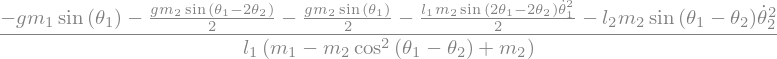

ddot_theta2=



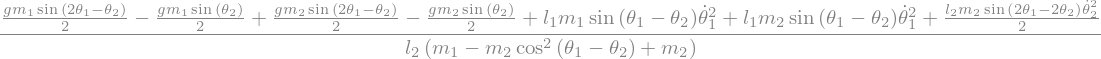

In [94]:
print(f"ddot_theta1=\n")
display(aceleracion1)
print(f"ddot_theta2=\n")
display(aceleracion2)

In [95]:
print(f"ddot_theta1=\n")
sp.print_latex(aceleracion1)
print(f"ddot_theta2=\n")
sp.print_latex(aceleracion2)

ddot_theta1=

\frac{- g m_{1} \sin{\left(\theta_{1}{\left(t \right)} \right)} - \frac{g m_{2} \sin{\left(\theta_{1}{\left(t \right)} - 2 \theta_{2}{\left(t \right)} \right)}}{2} - \frac{g m_{2} \sin{\left(\theta_{1}{\left(t \right)} \right)}}{2} - \frac{l_{1} m_{2} \sin{\left(2 \theta_{1}{\left(t \right)} - 2 \theta_{2}{\left(t \right)} \right)} \left(\frac{d}{d t} \theta_{1}{\left(t \right)}\right)^{2}}{2} - l_{2} m_{2} \sin{\left(\theta_{1}{\left(t \right)} - \theta_{2}{\left(t \right)} \right)} \left(\frac{d}{d t} \theta_{2}{\left(t \right)}\right)^{2}}{l_{1} \left(m_{1} - m_{2} \cos^{2}{\left(\theta_{1}{\left(t \right)} - \theta_{2}{\left(t \right)} \right)} + m_{2}\right)}
ddot_theta2=

\frac{\frac{g m_{1} \sin{\left(2 \theta_{1}{\left(t \right)} - \theta_{2}{\left(t \right)} \right)}}{2} - \frac{g m_{1} \sin{\left(\theta_{2}{\left(t \right)} \right)}}{2} + \frac{g m_{2} \sin{\left(2 \theta_{1}{\left(t \right)} - \theta_{2}{\left(t \right)} \right)}}{2} - \frac{g m_{2} \sin{\left(

In [96]:
# ============================================
# PARÁMETROS DEL SISTEMA
# ============================================
l1, l2 = 1.5, 1.0   # longitudes (m)
m1, m2 = 1.3, 1.0   # masas (kg)
g = 9.81             # gravedad (m/s^2)

# ============================================
# SISTEMA DE EDOs (desacoplado)
# ============================================
def pendulo_doble(t, y):
    """
    y = [theta1, theta2, omega1, omega2]
    
    Resuelve el sistema acoplado:
        theta1_ddot = A - B * theta2_ddot
        theta2_ddot = C - D * theta1_ddot
    """
    theta1, theta2, omega1, omega2 = y
    
    delta = theta1 - theta2
    sin_d = np.sin(delta)
    cos_d = np.cos(delta)
    
    # Términos independientes de las aceleraciones
    A = (-g*(m1 + m2)*np.sin(theta1) - l2*m2*sin_d*omega2**2) / (l1*(m1 + m2))
    C = (-g*np.sin(theta2) + l1*sin_d*omega1**2) / l2
    
    # Coeficientes de acoplamiento
    B = l2*m2*cos_d / (l1*(m1 + m2))
    D = l1*cos_d / l2
    
    # Solución del sistema 2x2
    denom = 1.0 - B*D
    
    theta1_ddot = (A - B*C) / denom
    theta2_ddot = (C - D*A) / denom
    
    return [omega1, omega2, theta1_ddot, theta2_ddot]

In [97]:
# ============================================
# INTEGRACIÓN NUMÉRICA
# ============================================
y0 = [np.pi/2, np.pi/2, 0.0, 0.0]   # ambos a 90°, sin velocidad
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], 2000)

sol = solve_ivp(pendulo_doble, t_span, y0, method='RK45', 
                t_eval=t_eval, rtol=1e-9, atol=1e-12)

# ============================================
# POSICIONES (sistema: x derecha, y abajo)
# ============================================
x1 = l1 * np.sin(sol.y[0])
y1 = l1 * np.cos(sol.y[0])
x2 = x1 + l2 * np.sin(sol.y[1])
y2 = y1 + l2 * np.cos(sol.y[1])

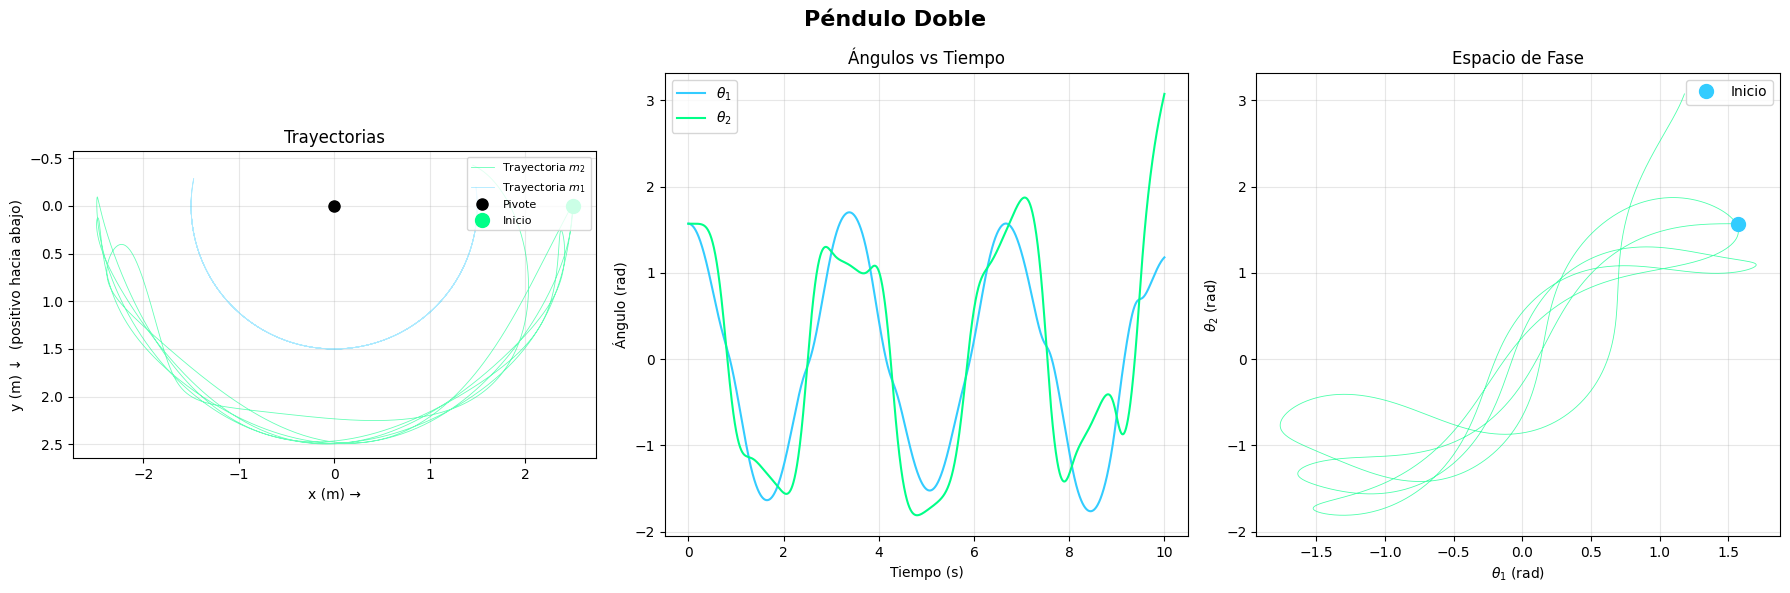

In [98]:
# ============================================
# GRÁFICAS
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Péndulo Doble', fontsize=16, fontweight='bold')

# --- 1. Trayectorias en el espacio físico ---
ax = axes[0]
ax.set_aspect('equal')

# Eje Y positivo hacia abajo: invertimos el eje
ax.invert_yaxis()

ax.plot(x2, y2, color='#00ff88', lw=0.6, alpha=0.6, label=r'Trayectoria $m_2$')
ax.plot(x1, y1, color='#33ccff', lw=0.6, alpha=0.4, label=r'Trayectoria $m_1$')
ax.plot(0, 0, 'ko', markersize=8, zorder=5, label='Pivote')
ax.plot(x2[0], y2[0], 'o', color='#00ff88', markersize=10, zorder=5, label='Inicio')

ax.set_xlabel('x (m) →')
ax.set_ylabel('y (m) ↓  (positivo hacia abajo)')
ax.set_title('Trayectorias')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

# --- 2. Ángulos vs tiempo ---
ax = axes[1]
ax.plot(sol.t, sol.y[0], label=r'$\theta_1$', color='#33ccff', lw=1.5)
ax.plot(sol.t, sol.y[1], label=r'$\theta_2$', color='#00ff88', lw=1.5)
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Ángulo (rad)')
ax.set_title('Ángulos vs Tiempo')
ax.legend()
ax.grid(True, alpha=0.3)

# --- 3. Espacio de fase ---
ax = axes[2]
ax.plot(sol.y[0], sol.y[1], color='#00ff88', lw=0.6, alpha=0.7)
ax.plot(sol.y[0, 0], sol.y[1, 0], 'o', color='#33ccff', markersize=10, label='Inicio')
ax.set_xlabel(r'$\theta_1$ (rad)')
ax.set_ylabel(r'$\theta_2$ (rad)')
ax.set_title('Espacio de Fase')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()